# Lab 9

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

> Q1. Load the SENTIMENT dataset and inspect text columns.  

In [19]:
df = pd.read_csv("test_CC.csv", encoding="latin1")
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797,27400.0,105
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044,2381740.0,18
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265,470.0,164
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272,1246700.0,26


In [20]:
df.dtypes

textID               object
text                 object
sentiment            object
Time of Tweet        object
Age of User          object
Country              object
Population -2020      int64
Land Area (Km²)     float64
Density (P/Km²)       int64
dtype: object

In [24]:
txt_coln = df.select_dtypes(include='object').columns
txt_coln

Index(['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User',
       'Country'],
      dtype='object')

In [25]:
df[txt_coln]

,textID,text,sentiment,Time of Tweet,Age of User,Country
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria
3,01082688c6,happy bday!,positive,morning,46-60,Andorra
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola
...,...,...,...,...,...,...
3529,e5f0e6ef4b,"its at 3 am, im very tired but i can`t sleep ...",negative,noon,21-30,Nicaragua
3530,416863ce47,All alone in this old house again. Thanks for...,positive,night,31-45,Niger
3531,6332da480c,I know what you mean. My little dog is sinkin...,negative,morning,46-60,Nigeria
3532,df1baec676,_sutra what is your next youtube video gonna b...,positive,noon,60-70,North Korea


> Q2. Perform basic string operations:  

> Q3. Convert text to lowercase  

In [31]:
df['lower_text'] = df["text"].astype(str).str.lower()
pd.DataFrame(df["lower_text"].head())

,lower_text
0,last session of the day http://twitpic.com/67ezh
1,shanghai is also really exciting (precisely -...
2,"recession hit veronique branquinho, she has to..."
3,happy bday!
4,http://twitpic.com/4w75p - i like it!!


> Q4. Remove punctuation  

In [36]:
df['clean_text'] = df['lower_text'].str.replace(r'[^\w\s]', '', regex=True)
pd.DataFrame(df['clean_text'])

,clean_text
0,last session of the day httptwitpiccom67ezh
1,shanghai is also really exciting precisely s...
2,recession hit veronique branquinho she has to ...
3,happy bday
4,httptwitpiccom4w75p i like it
...,...
3529,its at 3 am im very tired but i cant sleep bu...
3530,all alone in this old house again thanks for ...
3531,i know what you mean my little dog is sinking...
3532,_sutra what is your next youtube video gonna b...


> Q5. Count the number of positive, negative, and neutral sentiments.  

In [38]:
df['sentiment'].value_counts()

neutral     1430
positive    1103
negative    1001
Name: sentiment, dtype: int64

> Q6. Find the most frequently occurring words in positive reviews.  

In [56]:
positive_reviews = df[df['sentiment'].str.lower() == 'positive']['clean_text']

positive_words = " ".join(positive_reviews).split()

positive_word_freq = pd.Series(positive_words).value_counts()

print("Top 10 words in positive reviews:")
print(positive_word_freq.head(10))

Top 10 words in positive reviews:
i       511
the     359
to      354
a       273
you     264
and     200
my      182
it      176
for     162
good    143
dtype: int64


> Q7. Remove stopwords and display cleaned text.  

In [44]:
stopwords = {
    'the', 'is', 'in', 'and', 'to', 'of', 'it', 'this', 'that', 'a', 'an',
    'for', 'on', 'with', 'as', 'was', 'were', 'are', 'be', 'at', 'by',
    'from', 'or', 'but', 'not', 'have', 'has', 'had', 'i', 'you', 'he',
    'she', 'they', 'we', 'my', 'your', 'our', 'their'
}

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stopwords]
    return " ".join(filtered_words)

df['final_clean_text'] = df['clean_text'].apply(remove_stopwords)
pd.DataFrame(df['final_clean_text'])

,final_clean_text
0,last session day httptwitpiccom67ezh
1,shanghai also really exciting precisely skyscr...
2,recession hit veronique branquinho quit her co...
3,happy bday
4,httptwitpiccom4w75p like
...,...
3529,its 3 am im very tired cant sleep try
3530,all alone old house again thanks net which kee...
3531,know what mean little dog sinking into depress...
3532,_sutra what next youtube video gonna about lov...


> Q8. Create a word length distribution plot.  

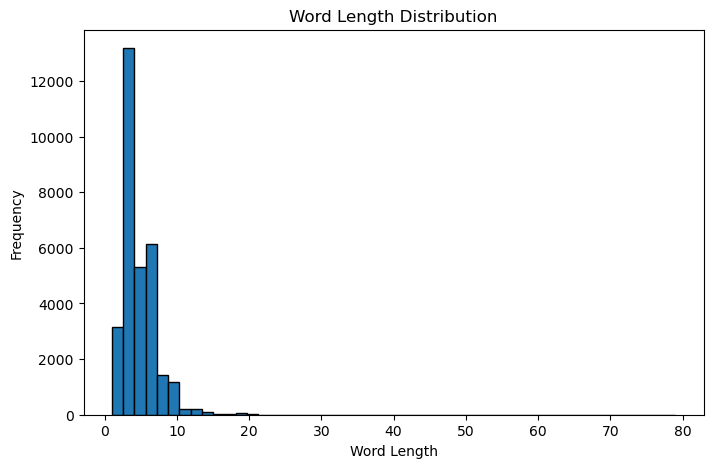

In [49]:
all_words = " ".join(df['final_clean_text']).split()
word_lengths = [len(word) for word in all_words]

plt.figure(figsize=(8,5))
plt.hist(word_lengths, bins=50, edgecolor='black')
plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()

> Q9. Generate a bar chart showing sentiment count.  

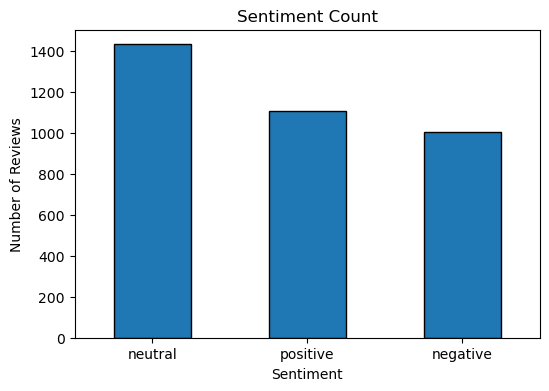

In [54]:
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', edgecolor='black')
plt.title("Sentiment Count")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

> Q10. Identify top keywords influencing negative sentiment.  

In [57]:
negative_reviews = df[df['sentiment'].str.lower() == 'negative']['final_clean_text']

negative_words = " ".join(negative_reviews).split()

negative_word_freq = pd.Series(negative_words).value_counts()

print("Top 10 keywords in negative reviews:")
print(negative_word_freq.head(10))

Top 10 keywords in negative reviews:
im      169
me      130
so      116
its      89
just     71
out      63
miss     61
all      58
sad      56
no       56
dtype: int64


> Q11. Write a short summary explaining how string processing helped sentiment analysis.  

Conclusion

The sentiment dataset was analyzed using string processing techniques such as lowercasing, punctuation removal, and stopword elimination. These methods improved text quality and made sentiment analysis more accurate. Positive reviews helped identify customer satisfaction factors, while negative reviews revealed common complaint keywords. Visualizations such as the word length distribution and sentiment count bar chart made the analysis easier to interpret. Overall, string processing plays an important role in converting unstructured text into useful business insights.